# Notebook 2: Dataset Pipeline for Deep Learning

## Objective

The feature-engineered dataset from Notebook 1 must be transformed into sequential samples suitable for deep learning models.

Unlike classical machine learning models, neural networks such as LSTMs and Transformers learn from ordered sequences rather than independent observations.

This notebook constructs those sequences while ensuring:

- No future information leakage
- Proper chronological train-validation-test split
- Feature scaling using only training data
- Efficient PyTorch datasets and dataloaders

The output of this notebook will be used directly by all subsequent models.

In [2]:
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
CONFIG = {
    "sequence_length": 60,
    "prediction_horizon": 5,
    "batch_size": 64,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15
}

## Load Dataset

The engineered dataset from Notebook 1 is loaded.

This dataset already contains engineered features and prediction targets.

In [4]:
df = pd.read_parquet(
    "processed_data/master_dataset.parquet"
)
print(df.shape)
df.head()

(2721, 99)


,Date,Close,High,Low,Open,Volume,Daily_Return,Rolling_Volatility,Return,Log_Return,...,Rolling_Low_10,Distance_From_High_10,Distance_From_Low_10,Rolling_High_20,Rolling_Low_20,Distance_From_High_20,Distance_From_Low_20,Range_Position,Breakout_20,Breakdown_20
0,2015-03-02,28.677841,28.942205,28.502341,28.713387,192386800,0.004904,0.012452,0.004904,0.004892,...,28.126907,0.966242,1.019587,29.679761,25.686247,1.001920,2.991594,0.749113,0,0
1,2015-03-03,28.737829,28.773375,28.455693,28.648969,151265200,0.002092,0.012344,0.002092,0.002090,...,28.126907,0.968263,1.021720,29.679761,26.024808,0.941932,2.713021,0.742286,0,0
2,2015-03-04,28.555660,28.782258,28.506790,28.680069,126665200,-0.006339,0.012551,-0.006339,-0.006359,...,28.126907,0.962126,1.015244,29.679761,26.179700,1.124101,2.375960,0.678834,0,0
3,2015-03-05,28.082468,28.602307,27.938068,28.564541,226068400,-0.016571,0.013352,-0.016571,-0.016710,...,27.938068,0.946182,1.005169,29.679761,26.309685,1.597293,1.772783,0.526036,0,0
4,2015-03-06,28.124681,28.740047,28.049150,28.524557,291368400,0.001503,0.013321,0.001503,0.001502,...,27.938068,0.947605,1.006680,29.679761,26.309685,1.555080,1.814996,0.538562,0,0


In [5]:
print(df.columns.tolist())

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return', 'Rolling_Volatility', 'Return', 'Log_Return', 'Price_Change', 'Previous_Close', 'Gap', 'High_Low_Range', 'Open_Close_Range', 'True_Range', 'Rolling_Mean', 'Rolling_STD', 'Rolling_Min', 'Rolling_Max', 'Rolling_Median', 'Rolling_Variance', 'Momentum_5', 'Momentum_10', 'Momentum_20', 'ROC_5', 'ROC_10', 'Volume_MA_5', 'Volume_MA_20', 'Relative_Volume', 'Volume_Change', 'Volume_Momentum', 'OBV', 'VWAP', 'Body', 'Upper_Wick', 'Lower_Wick', 'Full_Range', 'Body_Ratio', 'Upper_Wick_Ratio', 'Lower_Wick_Ratio', 'Body_to_Wick', 'ATR', 'Historical_Volatility', 'Parkinson_Volatility', 'Garman_Klass', 'EMA_9', 'EMA_21', 'EMA_50', 'EMA_200', 'MACD', 'EMA_12', 'EMA_26', 'Signal', 'MACD_Histogram', 'Rolling_Skew', 'Rolling_Kurtosis', 'Rolling_Zscore', 'Rolling_Max_Return', 'Rolling_Min_Return', 'Rolling_Return_STD', 'Future_Close', 'Future_Return', 'Target_Direction', 'Day', 'Month', 'Quarter', 'DayOfWeek', 'WeekOfYear', 'Close_Lag_1', '

## Feature Selection

Columns used only for bookkeeping or target generation are removed from the model inputs.

Target variables remain separate.

In [6]:
ignore = [

    "Date",

    "Future_Close",

    "Future_Return",

    "Target_Direction"

]

feature_columns = [

    c

    for c in df.columns

    if c not in ignore

]

X = df[feature_columns]

y = df["Future_Return"]

In [7]:
print("Number of Features:", len(feature_columns))

Number of Features: 95


## Chronological Train Validation Test Split

Financial time series must never be randomly shuffled.

The oldest observations are used for training, followed by validation, and finally testing on the most recent data.

In [8]:
n = len(df)

train_end = int(n * CONFIG["train_ratio"])

val_end = int(
    n *
    (
        CONFIG["train_ratio"] +
        CONFIG["val_ratio"]
    )
)

In [9]:
X_train = X.iloc[:train_end]

X_val = X.iloc[train_end:val_end]

X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]

y_val = y.iloc[train_end:val_end]

y_test = y.iloc[val_end:]

In [10]:
print(len(X_train))

print(len(X_val))

print(len(X_test))

1904
408
409


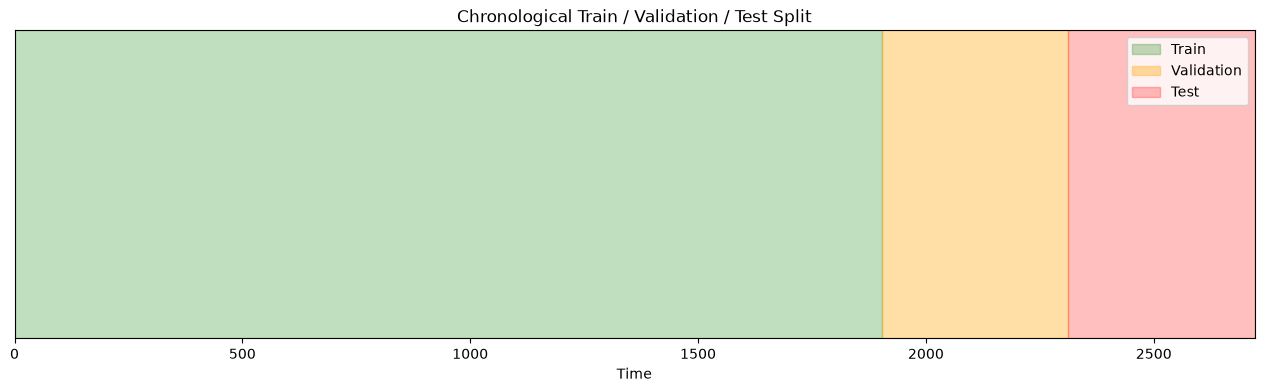

In [14]:
plt.figure(figsize=(16, 4))

plt.axvspan(
    0,
    train_end,
    color="green",
    alpha=0.25,
    label="Train"
)

plt.axvspan(
    train_end,
    val_end,
    color="orange",
    alpha=0.35,
    label="Validation"
)

plt.axvspan(
    val_end,
    len(df),
    color="red",
    alpha=0.25,
    label="Test"
)

plt.xlim(0, len(df))

plt.yticks([])

plt.xlabel("Time")

plt.title("Chronological Train / Validation / Test Split")

plt.legend()

plt.show()

In [15]:
print(f"Total Samples : {len(df)}")
print(f"Train         : {len(X_train)}")
print(f"Validation    : {len(X_val)}")
print(f"Test          : {len(X_test)}")

Total Samples : 2721
Train         : 1904
Validation    : 408
Test          : 409


# Feature Scaling

Neural networks are sensitive to differences in feature magnitude.

To prevent data leakage, the scaler is fitted **only on the training data**.

The fitted scaler is then applied to the validation and test sets without recalculating statistics.

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [18]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(1904, 95)
(408, 95)
(409, 95)


In [21]:
print(np.mean(X_train_scaled[:,0]))
print(np.std(X_train_scaled[:,0]))

-5.970947359328573e-17
1.0


# Sliding Window Generation

Deep learning models operate on sequences rather than individual observations.

A sliding window converts the continuous financial time series into supervised learning samples.

Example

Input

Day 1 ... Day 60

Target

Future Return on Day 65

In [22]:
sequence_length = CONFIG["sequence_length"]

In [23]:
def create_sequences(X, y, seq_len):

    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):

        X_seq.append(
            X[i:i+seq_len]
        )

        y_seq.append(
            y.iloc[i+seq_len]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

In [24]:
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    sequence_length
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val,
    sequence_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    sequence_length
)

In [25]:
print("Train:", X_train_seq.shape)

print("Validation:", X_val_seq.shape)

print("Test:", X_test_seq.shape)

Train: (1844, 60, 95)
Validation: (348, 60, 95)
Test: (349, 60, 95)


In [27]:
sample = 0
feature = feature_columns.index("Close")

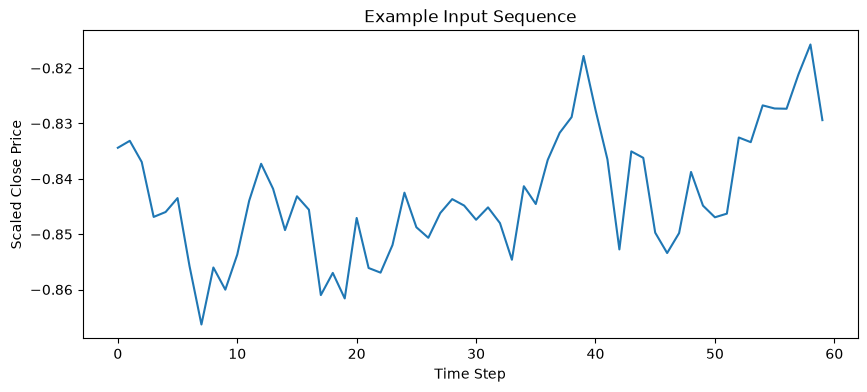

In [28]:
plt.figure(figsize=(10,4))
plt.plot(X_train_seq[sample,:,feature])
plt.title("Example Input Sequence")
plt.xlabel("Time Step")
plt.ylabel("Scaled Close Price")
plt.show()

# Custom PyTorch Dataset

PyTorch models expect data in the form of Dataset and DataLoader objects.

A custom Dataset provides indexed access to input sequences and corresponding targets while allowing efficient mini-batch loading during training.

In [29]:
class StockDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [30]:
train_dataset = StockDataset(X_train_seq, y_train_seq)
val_dataset = StockDataset(X_val_seq, y_val_seq)
test_dataset = StockDataset(X_test_seq, y_test_seq)

In [31]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1844
348
349


# DataLoader

DataLoaders divide the dataset into mini-batches for efficient GPU training.

Training batches are shuffled, while validation and test batches preserve chronological order.

In [32]:
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

In [33]:
print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

29
6
6


# Batch Inspection

Before training any model, verify that the DataLoader returns tensors with the expected dimensions.

In [34]:
X_batch, y_batch = next(iter(train_loader))

In [35]:
print("Input Shape :", X_batch.shape)
print("Target Shape:", y_batch.shape)

Input Shape : torch.Size([64, 60, 95])
Target Shape: torch.Size([64])


In [36]:
print(X_batch.dtype)
print(y_batch.dtype)

torch.float32
torch.float32


In [37]:
sample = X_batch[0]
print(sample.shape)

torch.Size([60, 95])


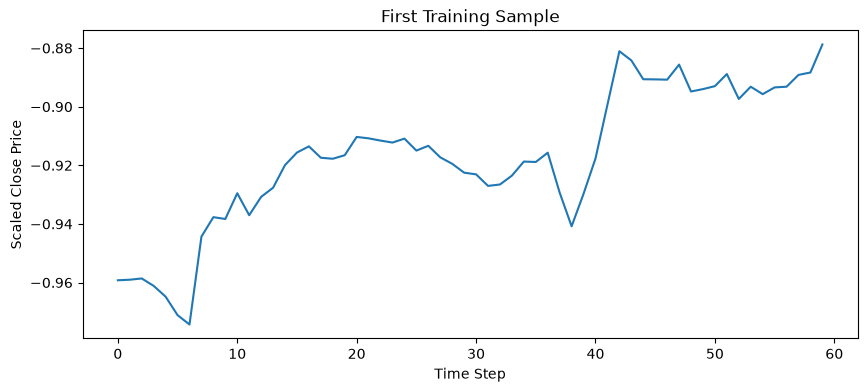

In [38]:
feature = feature_columns.index("Close")

plt.figure(figsize=(10,4))
plt.plot(sample[:, feature].numpy())
plt.title("First Training Sample")
plt.xlabel("Time Step")
plt.ylabel("Scaled Close Price")
plt.show()

# Save Dataset Pipeline

The processed sequences, fitted scaler, and feature metadata are saved for reproducibility.

Subsequent notebooks can load these files directly without repeating preprocessing.

In [39]:
import joblib
import os

os.makedirs("pipeline", exist_ok=True)

In [40]:
np.save("pipeline/X_train.npy", X_train_seq)
np.save("pipeline/y_train.npy", y_train_seq)

np.save("pipeline/X_val.npy", X_val_seq)
np.save("pipeline/y_val.npy", y_val_seq)

np.save("pipeline/X_test.npy", X_test_seq)
np.save("pipeline/y_test.npy", y_test_seq)

In [41]:
joblib.dump(scaler, "pipeline/scaler.pkl")

['pipeline/scaler.pkl']

In [42]:
joblib.dump(feature_columns, "pipeline/feature_columns.pkl")

['pipeline/feature_columns.pkl']

In [43]:
print("="*60)
print("NOTEBOOK 2 COMPLETE")
print("="*60)

print("Training Sequences :", X_train_seq.shape)
print("Validation Sequences:", X_val_seq.shape)
print("Testing Sequences :", X_test_seq.shape)

print("\nFeatures :", len(feature_columns))
print("Sequence Length :", CONFIG["sequence_length"])
print("Prediction Horizon :", CONFIG["prediction_horizon"])

NOTEBOOK 2 COMPLETE
Training Sequences : (1844, 60, 95)
Validation Sequences: (348, 60, 95)
Testing Sequences : (349, 60, 95)

Features : 95
Sequence Length : 60
Prediction Horizon : 5
